# Student Stress Prediction Using Machine Learning

## Objective

The objective of this project is to predict whether a student is likely to experience high or low stress based on academic and different behavioural factors.

The project includes:
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Model Building
- Model Evaluation
- Comparison of Machine Learning Algorithms

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('student-lifestyle-and-stress-dataset.csv')
df.info()
df.shape
df.head()
df.isnull().sum()
df.describe()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


,count,mean,std,min,25%,50%,75%,max
Sleep_Hours,24167.0,6.458948,1.504228,2.008586,5.438360,6.542566,7.531571,9.997527
Study_Hours,24223.0,4.696477,2.240148,-1.433434,3.078230,4.538138,6.135670,22.444460
Social_Media_Hours,24188.0,3.555614,1.901528,0.000040,2.152249,3.500709,4.864312,9.962134
Attendance,24195.0,81.270961,12.052045,-5.000000,73.738894,81.942959,90.106859,120.000000
Exam_Pressure,24230.0,5.369748,2.394003,1.000000,4.000000,5.000000,7.000000,10.000000
Family_Support,24209.0,5.798298,2.232371,1.000000,4.000000,6.000000,7.000000,10.000000
Month,24186.0,6.500992,3.455308,1.000000,3.000000,6.000000,10.000000,12.000000
Stress_Level,25500.0,0.299882,0.458215,0.000000,0.000000,0.000000,1.000000,1.000000


In [130]:
df.nunique()
df.min(numeric_only = True)

Sleep_Hours           2.008586
Study_Hours          -1.433434
Social_Media_Hours    0.000040
Attendance           -5.000000
Exam_Pressure         1.000000
Family_Support        1.000000
Month                 1.000000
Stress_Level          0.000000
dtype: float64

## Handling the negative values (errors)

In [131]:
(df['Study_Hours'] < 0).sum()
df.loc[df['Study_Hours'] < 0, 'Study_Hours'] = np.nan
(df['Study_Hours'] < 0).sum()

0

In [132]:
(df['Attendance'] < 0).sum()
df.loc[df['Attendance'] < 0 , 'Attendance'] = np.nan
(df['Attendance'] < 0).sum()

0

## Handling the missing values

In [133]:
df[df['Student_Type'] == 'college'].info()
df[df['Student_Type'] == 'school'].info()
df['Student_Type'].nunique()
df['Student_Type'].unique()
df['Student_Type'].mode()
df['Student_Type'].unique()

<class 'pandas.core.frame.DataFrame'>
Index: 13391 entries, 2 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        13391 non-null  object 
 1   Sleep_Hours         12687 non-null  float64
 2   Study_Hours         12711 non-null  float64
 3   Social_Media_Hours  12703 non-null  float64
 4   Attendance          12687 non-null  float64
 5   Exam_Pressure       12724 non-null  float64
 6   Family_Support      12690 non-null  float64
 7   Month               12677 non-null  float64
 8   Stress_Level        13391 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.0+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 6021 entries, 0 to 25498
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        6021 non-null   object 
 1   Sleep_Hours         5733 non-null   float6

array(['school', 'college', 'working_student', nan], dtype=object)

In [134]:
df['Student_Type'] = df['Student_Type'].fillna(df['Student_Type'].mode()[0])
df['Student_Type'].isnull().sum()

0

In [135]:
df['Exam_Pressure'].mode()
df['Exam_Pressure'] = df['Exam_Pressure'].fillna(df['Exam_Pressure'].mode()[0])
df['Exam_Pressure'].isnull().sum()

0

In [136]:
df['Family_Support'].unique()
df['Family_Support'].mode()
df['Family_Support'] = df['Family_Support'].fillna(df['Family_Support'].mode()[0])
df['Family_Support'].isnull().sum()

0

In [137]:
df['Month'].unique()
df['Month'].mode()
df['Month'] = df['Month'].fillna(df['Month'].mode()[0])
df['Month'].isnull().sum()

0

## NAs in the numeric columns

In [138]:
num_cols = ['Attendance', 'Social_Media_Hours', 'Study_Hours', 'Sleep_Hours']
NA = df[num_cols].mean()
df[num_cols] = df[num_cols].fillna(NA)
df[num_cols].isnull().sum()
df.isnull().sum()

Student_Type          0
Sleep_Hours           0
Study_Hours           0
Social_Media_Hours    0
Attendance            0
Exam_Pressure         0
Family_Support        0
Month                 0
Stress_Level          0
dtype: int64

## Getting rid of the duplicated rows

In [139]:
df.duplicated().sum()   #24
df[df.duplicated()]

df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())  #to check genuine duplicates
df = df.drop_duplicates()
df.duplicated().sum()

0

## Use onehot coding for the column 'Student_Type'

In [140]:
df_encoded = pd.get_dummies(df, columns = ['Student_Type'], drop_first = True)
df_encoded

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level,Student_Type_school,Student_Type_working_student
0,6.868702,1.711722,3.176942,81.374489,8.0,7.0,2.0,1,True,False
1,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1,True,False
2,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1,False,False
3,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0,True,False
4,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1,False,False
...,...,...,...,...,...,...,...,...,...,...
25495,7.803069,7.328193,2.018277,75.435607,5.0,1.0,12.0,0,False,False
25496,6.734607,2.680109,3.355559,63.387386,8.0,9.0,2.0,1,True,False
25497,7.701671,2.631250,2.948252,79.818930,4.0,3.0,4.0,1,False,False
25498,5.903426,3.450424,6.823894,96.680773,2.0,6.0,6.0,0,True,False


## Finding the correlation matrix

In [141]:
corr = df_encoded.corr()

## Visualizing Through a HeatMap

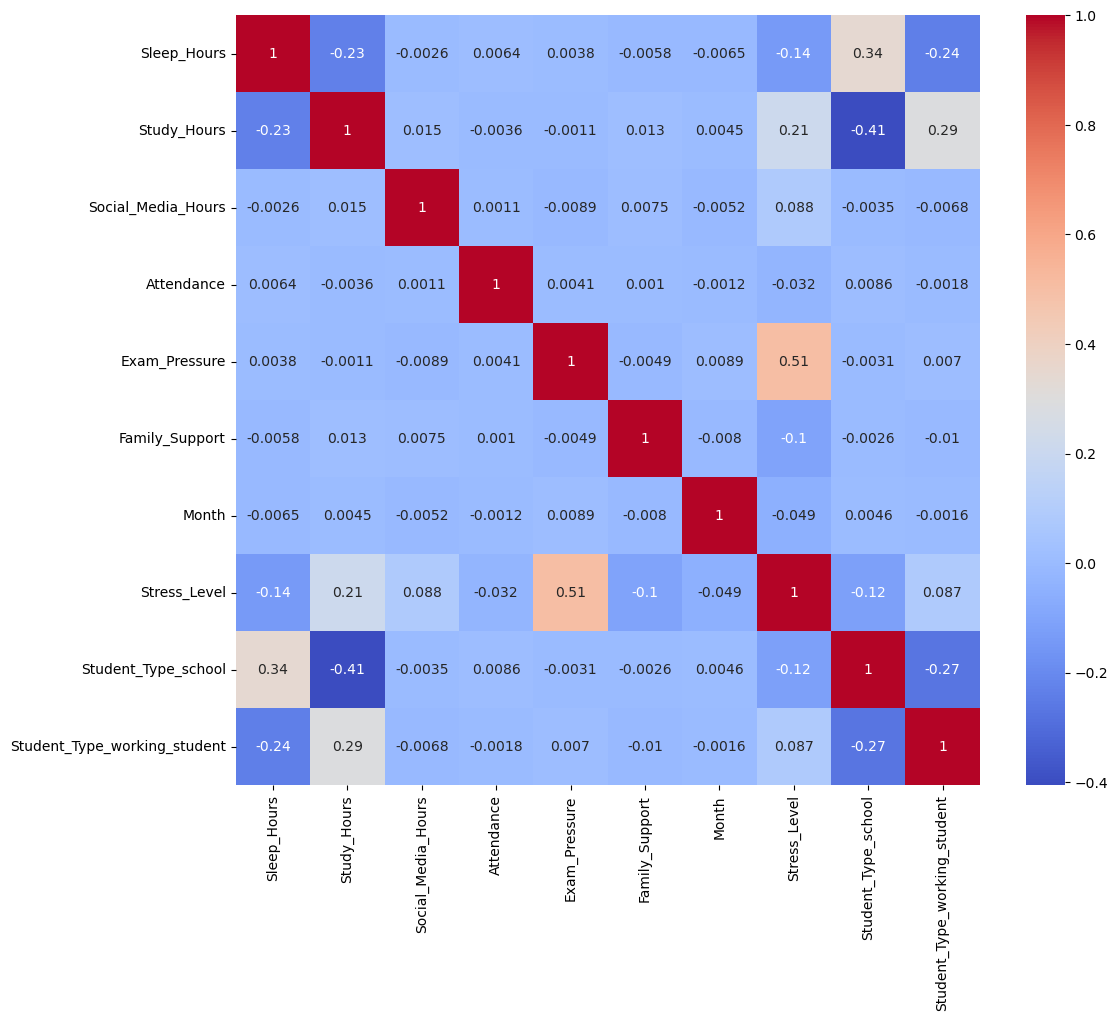

In [142]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [143]:
# Getting ready for Logistic Regression
#Creating Features and the target

X = df_encoded.drop('Stress_Level', axis = 1)
y = df_encoded['Stress_Level']
X.shape
y.shape

(25476,)

## Splitting the data

In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 13)
X_train.shape
X_test.shape
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (20380, 9)
X_test : (5096, 9)
y_train: (20380,)
y_test : (5096,)


## Standardizing certain numerical features

In [145]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_train

array([[ 0.08840384, -0.34720346,  0.66323015, ..., -1.54162585,
        -0.55709795, -0.4827619 ],
       [-0.71036019, -0.55237927,  0.38433069, ...,  0.48631672,
         1.79501647, -0.4827619 ],
       [-2.3326885 ,  0.32348826, -1.38697978, ...,  1.64514105,
        -0.55709795,  2.0714145 ],
       ...,
       [-0.57858003,  0.87615297, -0.27048206, ...,  1.06572889,
        -0.55709795,  2.0714145 ],
       [ 1.95337683, -0.84876106, -0.41873246, ..., -1.25191977,
         1.79501647, -0.4827619 ],
       [ 0.55145188,  0.349465  ,  0.27944943, ..., -1.25191977,
        -0.55709795, -0.4827619 ]])

In [146]:
X_test = scaler.transform(X_test)
X_test

array([[-3.78141491e-02, -9.73316343e-01,  1.33505446e-01, ...,
        -9.62213690e-01, -5.57097954e-01, -4.82761899e-01],
       [-4.64107819e-01, -9.24098347e-01, -8.96475355e-01, ...,
         4.86316721e-01, -5.57097954e-01, -4.82761899e-01],
       [-1.34090112e+00, -1.17510394e+00,  7.88747682e-01, ...,
         1.06572889e+00, -5.57097954e-01, -4.82761899e-01],
       ...,
       [-1.04646835e-01,  4.49837482e-04,  2.20675676e+00, ...,
        -9.30954432e-02, -5.57097954e-01, -4.82761899e-01],
       [-1.41950813e-01, -4.59695850e-01, -1.26497944e+00, ...,
        -3.82801526e-01, -5.57097954e-01, -4.82761899e-01],
       [-9.04782789e-01, -1.19028230e+00, -7.03951386e-01, ...,
         1.06572889e+00, -5.57097954e-01,  2.07141450e+00]])

## Applying Logistic Regression

In [147]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Testing the model

In [148]:
y_pred = model.predict(X_test)
y_pred
y_pred[:15]

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0], dtype=int64)

In [149]:
y_test[:15]

9188     0
2585     0
23225    0
13842    1
11981    1
11756    0
20136    0
4586     1
3019     0
14495    0
18580    0
5189     0
4142     1
6949     0
4168     1
Name: Stress_Level, dtype: int64

## Evaluating the model

In [150]:
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8057299843014128


In [151]:
print(confusion_matrix(y_test, y_pred))

[[3174  346]
 [ 644  932]]


In [152]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      3520
           1       0.73      0.59      0.65      1576

    accuracy                           0.81      5096
   macro avg       0.78      0.75      0.76      5096
weighted avg       0.80      0.81      0.80      5096



## Visualize the confusion matrix

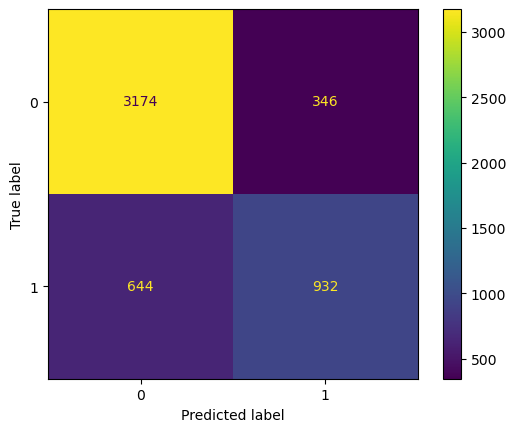

In [153]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [154]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
4,Exam_Pressure,1.678995
1,Study_Hours,0.640371
2,Social_Media_Hours,0.310653
8,Student_Type_working_student,0.001129
7,Student_Type_school,-0.030333
3,Attendance,-0.105705
6,Month,-0.202751
0,Sleep_Hours,-0.325383
5,Family_Support,-0.372243


## Comparing with other models

In [155]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_pred_dt

array([1, 1, 1, ..., 1, 0, 1], dtype=int64)

In [156]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7403846153846154
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      3520
           1       0.58      0.57      0.58      1576

    accuracy                           0.74      5096
   macro avg       0.70      0.69      0.69      5096
weighted avg       0.74      0.74      0.74      5096



In [157]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([0, 1, 0, ..., 1, 0, 1], dtype=int64)

In [158]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8078885400313972
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      3520
           1       0.74      0.59      0.65      1576

    accuracy                           0.81      5096
   macro avg       0.78      0.75      0.76      5096
weighted avg       0.80      0.81      0.80      5096



In [159]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.777668759811617
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      3520
           1       0.68      0.54      0.60      1576

    accuracy                           0.78      5096
   macro avg       0.74      0.71      0.72      5096
weighted avg       0.77      0.78      0.77      5096



In [160]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create an empty list
results = []

# Logistic Regression
results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
})

# Decision Tree
results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1 Score': f1_score(y_test, y_pred_dt)
})

# Random Forest
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1 Score': f1_score(y_test, y_pred_rf)
})

# KNN
results.append({
    'Model': 'K-Nearest Neighbors',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1 Score': f1_score(y_test, y_pred_knn)
})

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Round values to 3 decimal places
results_df = results_df.round(3)

# Sort by Accuracy
results_df = results_df.sort_values(by='Accuracy', ascending=False)

# Reset index
results_df.reset_index(drop=True, inplace=True)

# Display
print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score
0        Random Forest     0.808      0.737   0.589     0.655
1  Logistic Regression     0.806      0.729   0.591     0.653
2  K-Nearest Neighbors     0.778      0.678   0.536     0.598
3        Decision Tree     0.740      0.582   0.569     0.576


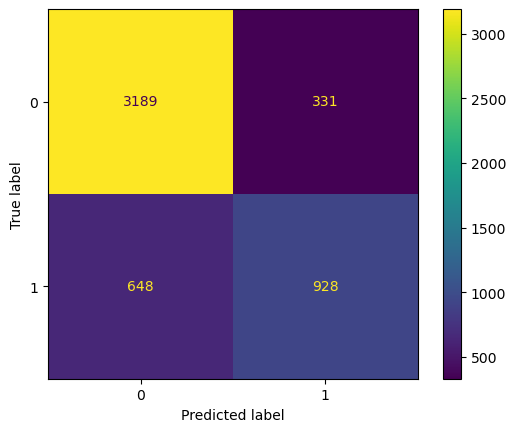

In [161]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

In [162]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
4,Exam_Pressure,0.305256
1,Study_Hours,0.163359
0,Sleep_Hours,0.134147
2,Social_Media_Hours,0.127964
3,Attendance,0.119184
6,Month,0.066311
5,Family_Support,0.061165
8,Student_Type_working_student,0.012329
7,Student_Type_school,0.010285


## Conclusion

Random Forest achieved the highest accuracy (80.8%).

Logistic Regression produced nearly identical performance while remaining easier to interpret.

Decision Tree showed the weakest performance among the evaluated models.

Logistic Regression achieved nearly the same performance as Random Forest while offering greater interpretability, making it a strong baseline model.